In [1]:
# 1. IMPORTATION DES BIBLIOTHÈQUES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Pour la sauvegarde

# Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, PrecisionRecallDisplay, f1_score)

# Imbalanced-Learn (Pour le Pipeline SMOTE)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuration
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques chargées avec succès.")

✅ Bibliothèques chargées avec succès.


In [2]:
# 2. CHARGEMENT ET PRÉPARATION DU DATASET
df = pd.read_csv('manufacturing_defect_dataset.csv')

# Correction de la logique (0->1 et 1->0 pour que 1 soit le défaut)
df['DefectStatus'] = df['DefectStatus'].replace({0: 1, 1: 0})

In [3]:
# 3. SIMULATION DE DÉFAUTS RARES (~1.5%)
df_normal = df[df['DefectStatus'] == 0]
df_defect = df[df['DefectStatus'] == 1]

# On garde seulement 45 défauts pour simuler la rareté
df_defect_rare = df_defect.sample(n=45, random_state=42)

# Reconstruction du dataset
df_final = pd.concat([df_normal, df_defect_rare])
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDistribution Scénario Rare :")
print(df_final['DefectStatus'].value_counts(normalize=True) * 100)



Distribution Scénario Rare :
DefectStatus
0    98.374277
1     1.625723
Name: proportion, dtype: float64


In [4]:
# 4. SPLIT TRAIN / TEST
X = df_final.drop('DefectStatus', axis=1)
y = df_final['DefectStatus']

# Stratify est important ici pour garder le % de défauts dans le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


Train shape: (1937, 16)
Test shape: (831, 16)


In [5]:
# 5. CONSTRUCTION DU PIPELINE (Imputer + SMOTE + RF)
# L'utilisation de ImbPipeline empêche le Data Leakage du SMOTE
pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Gère les NaN
    ('smote', SMOTE(random_state=42)),              # Génère des défauts synthétiques
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1)) # Modèle
])

# 6. OPTIMISATION (GRIDSEARCH)
# Note : Les paramètres doivent avoir le préfixe 'model__'
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, None],
    'model__class_weight': ['balanced', None]
}

print("\n⏳ Démarrage du GridSearch (Optimisation)...")
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1',  # On optimise le F1-score car c'est déséquilibré
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print(f"✅ Meilleurs paramètres : {grid_search.best_params_}")



⏳ Démarrage du GridSearch (Optimisation)...
✅ Meilleurs paramètres : {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__n_estimators': 200}


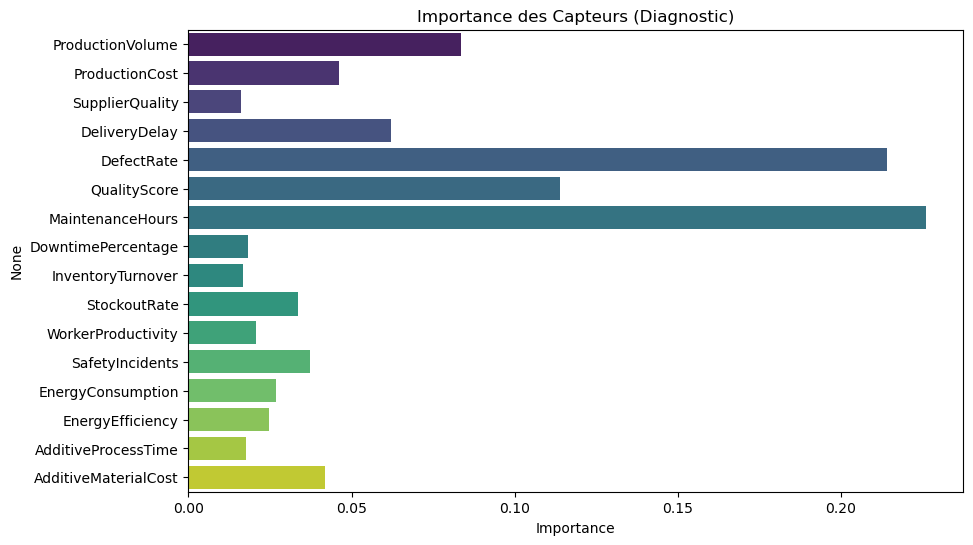

<Figure size 800x600 with 0 Axes>

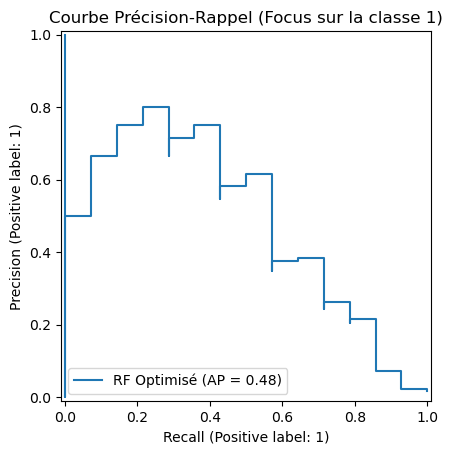


📏 Seuil optimal trouvé : 0.50 (F1 Score : 0.59)

--- RAPPORT FINAL (Après Optimisation du Seuil) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       817
           1       0.62      0.57      0.59        14

    accuracy                           0.99       831
   macro avg       0.80      0.78      0.79       831
weighted avg       0.99      0.99      0.99       831



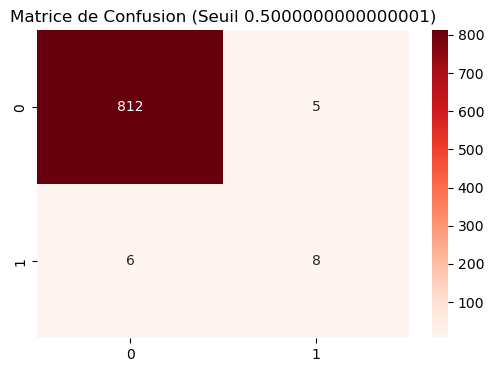

In [6]:
# 7. ÉVALUATION AVANCÉE & INTERPRÉTABILITÉ

# A. Feature Importance (Pourquoi une pièce est défectueuse ?)
rf_model = best_pipeline.named_steps['model']
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title("Importance des Capteurs (Diagnostic)")
plt.xlabel("Importance")
plt.show()

# B. Courbe Précision-Rappel (PR Curve)
plt.figure(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(
    best_pipeline, X_test, y_test, name="RF Optimisé"
)
plt.title("Courbe Précision-Rappel (Focus sur la classe 1)")
plt.show()

# 8. RECHERCHE DU MEILLEUR SEUIL (THRESHOLD TUNING)
# Au lieu de couper à 0.5, on cherche le seuil qui maximise le F1
y_probs = best_pipeline.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.05)

for thresh in thresholds:
    y_pred_temp = (y_probs >= thresh).astype(int)
    current_f1 = f1_score(y_test, y_pred_temp)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"\n📏 Seuil optimal trouvé : {best_threshold:.2f} (F1 Score : {best_f1:.2f})")

# Prédiction finale avec le seuil optimisé
y_pred_final = (y_probs >= best_threshold).astype(int)

print("\n--- RAPPORT FINAL (Après Optimisation du Seuil) ---")
print(classification_report(y_test, y_pred_final))

# Matrice de confusion
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Reds')
plt.title(f"Matrice de Confusion (Seuil {best_threshold})")
plt.show()

In [7]:
# 9. SAUVEGARDE COMPLÈTE (POUR DÉPLOIEMENT)
production_pack = {
    'pipeline': best_pipeline,       # Le modèle complet
    'threshold': best_threshold,     # Le seuil à utiliser
    'features': list(X.columns),     # Les noms des colonnes
    'description': "Modèle RF (1.5% Defauts) - Pipeline SMOTE"
}

joblib.dump(production_pack, 'modele_industriel_rare.pkl')
print("\n💾 Pack de déploiement sauvegardé : 'modele_industriel_rare.pkl'")


💾 Pack de déploiement sauvegardé : 'modele_industriel_rare.pkl'
